# Proyección de Ventas Netas - Urvet México

## Metodología

El presente proyecto sigue una metodología estructurada de Ciencia de Datos aplicada a Series de Tiempo (Forecasting). El flujo de trabajo abarca desde la extracción y consolidación de registros históricos hasta el análisis descriptivo y la preparación de los datos (Feature Engineering) para los modelos predictivos (SARIMAX, Prophet, LSTM, KNN y Regresión Logística).

---

### Contexto general de la empresa

**Grupo Urvet** es una empresa mexicana familiar con más de 29 años de trayectoria, posicionada como uno de los distribuidores a nivel nacional más importantes en el sector especializado de la salud y nutrición animal. 

* **Portafolio principal:** Son distribuidores a nivel nacional de alimentos super premium (como *Diamond Pet Foods* y *Taste of the Wild*) y son representantes exclusivos del laboratorio **MSD** (enfocado en medicamentos e innovación para prevención y tratamiento de enfermedades en mascotas).
* **Operación y Alcance:** Cuentan con su Matriz en Guadalajara, Jalisco, y una extensa red de Centros de Distribución (CEDIS) en puntos clave de la República (CDMX, Monterrey, Querétaro, Tijuana, Culiacán, León, entre otros).
* **Mercado Objetivo:** Canal especializado que incluye clínicas veterinarias, hospitales veterinarios, pet shops y criaderos.

**El Problema de Negocio:**
Dada la naturaleza de su catálogo, una correcta planificación de inventario es vital para la rentabilidad de los CEDIS. El objetivo de este proyecto es **proyectar las ventas netas del mes de abril de 2026**, entendiendo la "Venta Neta" como el monto real ingresado tras la aplicación de descuentos comerciales y la deducción de devoluciones.

---

### Datos

Los datos provienen de los reportes internos de rentabilidad de Urvet, extraídos del sistema central de la empresa.

* **Estructura:** Se dispone de archivos mensuales en formato `.xlsx` y `.csv` que abarcan el histórico transaccional de los años 2024, 2025 y el primer trimestre de 2026.
* **Variable Objetivo (Target):** `subtotalmn` (Calculada a partir de los montos de facturación, descuentos y devoluciones).
* **Volumen:** Aproximadamente 700,000 registros transaccionales en su forma cruda.
* **Granulidad:** Cada uno de los registros indica una línea asociada a una factura, por lo que, pueden existir múltiples códigos de facturas `doc_id` para varios registros, pero estos registros relacionados deben en la fecha en custión, deben coincidir exactamente con el cliente `customer_id` y agente `route_id` que están involucrados,

---

## Recursos y configuraciones base

In [121]:
import sys
import os
from pathlib import Path
import glob
import openpyxl

root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

print(f'Base directory: {root_path}')

import config.settings as config

import pandas as pd
pd.set_option('display.float_format', '{:,.2f}'.format)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Base directory: /Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/universidad/LIACD/S3/JAPI


### EDA (Análisis Exploratorio de Datos)

El objetivo de esta fase no es predecir, sino entender el comportamiento histórico de las ventas de Urvet, identificar patrones estacionales (ej. picos de venta en ciertas quincenas), limpiar anomalías y generar una "Fuente de Verdad" única que alimentará a los 4 especialistas en modelado del equipo.

#### 1. Recopilación

Como primer paso, consolidaremos todos los reportes mensuales aislados alojados en el directorio `data/` en un único *DataFrame* continuo para evaluar la serie de tiempo en su totalidad.

In [122]:
data_dir = Path(config.DATA_DIR) / "*.xlsx"
print(f"Data directory: '{data_dir}'")

files = glob.glob(str(data_dir))
files.sort()

if not files:
    print(f"No se encontraron archivos con el patrón '{data_dir}'")
else:
    print(f"Archivo encontrado: {len(files)}")

Data directory: '/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/universidad/LIACD/S3/JAPI/data/*.xlsx'
Archivo encontrado: 27


In [123]:
all_data = []

for file in files:
    try:
        if format == '.csv':
            df_temp = pd.read_csv(file)
        else:
            df_temp = pd.read_excel(file)

        if not df_temp.empty:
            df_temp['source_file'] = Path(file).name
            all_data.append(df_temp)
    except Exception as e:
        print(f"Error al leer {file}: {e}")

raw_data = pd.concat(all_data, ignore_index=True)
raw_data

,lugar,falta_fac,ctototmn,subtotalmn,ventacan,ventamon,devolucan,devolumon,utilidad,cant_surt,...,nom_cte,cve_factu,no_fac,doc_id,cur_id,nregavg,des_cse,des_lug,nom_age,source_file
0,GENERAL,2026-03-03,426.01,846.00,1,846.00,0,0.00,419.99,1,...,RIBERAS PETS STORE,GDL,482565,GDL 482565,VN,1,DIAMOND NATURALS,ALMACEN GENERAL,VTAS AXEL MARTINEZ 59-GDL,20260503T101029.918-act_mar_08.xlsx
1,GENERAL,2026-03-03,503.00,"1,001.20",3,"1,001.20",0,0.00,498.20,3,...,RIBERAS PETS STORE,GDL,482565,GDL 482565,VN,1,DIAMOND NATURALS,ALMACEN GENERAL,VTAS AXEL MARTINEZ 59-GDL,20260503T101029.918-act_mar_08.xlsx
2,GENERAL,2026-03-03,821.79,"1,568.42",1,"1,568.42",0,0.00,746.64,1,...,RIBERAS PETS STORE,GDL,482565,GDL 482565,VN,1,TASTE OF THE WILD,ALMACEN GENERAL,VTAS AXEL MARTINEZ 59-GDL,20260503T101029.918-act_mar_08.xlsx
3,GENERAL,2026-03-03,281.40,738.07,12,738.07,0,0.00,456.67,12,...,RIBERAS PETS STORE,GDL,482565,GDL 482565,VN,1,DIAMOND NATURALS,ALMACEN GENERAL,VTAS AXEL MARTINEZ 59-GDL,20260503T101029.918-act_mar_08.xlsx
4,GENERAL,2026-03-03,295.44,628.97,24,628.97,0,0.00,333.53,24,...,RIBERAS PETS STORE,GDL,482565,GDL 482565,VN,1,DIAMOND NATURALS,ALMACEN GENERAL,VTAS AXEL MARTINEZ 59-GDL,20260503T101029.918-act_mar_08.xlsx
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
658364,CDMX,2026-02-27,295.44,628.96,24,628.96,0,0.00,333.52,24,...,JUAN CARLOS ITURBE NOLASCO,MX,69403,MX 69403,VN,1,DIAMOND NATURALS,CDMX- Vallejo,MARTHA Venustiano Carranza R128 CDMX,Copia de rentabilidad_2026_02.xlsx
658365,CDMX,2026-02-27,281.40,763.74,12,763.74,0,0.00,482.34,12,...,JUAN CARLOS ITURBE NOLASCO,MX,69403,MX 69403,VN,1,DIAMOND NATURALS,CDMX- Vallejo,MARTHA Venustiano Carranza R128 CDMX,Copia de rentabilidad_2026_02.xlsx
658366,CDMX,2026-02-26,406.03,589.33,1,589.33,0,0.00,183.30,1,...,LUCILA MARILU RODRIGUEZ GALLEGOS,MX,69257,MX 69257,VN,1,VETOQUINOL,CDMX- Vallejo,Karla - Texcoco CDMX,Copia de rentabilidad_2026_02.xlsx
658367,CDMX,2026-02-26,426.24,673.98,1,673.98,0,0.00,247.74,1,...,LUCILA MARILU RODRIGUEZ GALLEGOS,MX,69257,MX 69257,VN,1,VETOQUINOL,CDMX- Vallejo,Karla - Texcoco CDMX,Copia de rentabilidad_2026_02.xlsx


In [124]:
raw_data.columns

Index(['lugar', 'falta_fac', 'ctototmn', 'subtotalmn', 'ventacan', 'ventamon',
       'devolucan', 'devolumon', 'utilidad', 'cant_surt', 'cse_prod',
       'cve_age', 'cve_cte', 'cve_prod', 'desc_prod', 'nom_cte', 'cve_factu',
       'no_fac', 'doc_id', 'cur_id', 'nregavg', 'des_cse', 'des_lug',
       'nom_age', 'source_file'],
      dtype='str')

In [125]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 658369 entries, 0 to 658368
Data columns (total 25 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   lugar        658369 non-null  str           
 1   falta_fac    658369 non-null  datetime64[us]
 2   ctototmn     658369 non-null  float64       
 3   subtotalmn   658369 non-null  float64       
 4   ventacan     658369 non-null  int64         
 5   ventamon     658369 non-null  float64       
 6   devolucan    658369 non-null  int64         
 7   devolumon    658369 non-null  float64       
 8   utilidad     658369 non-null  float64       
 9   cant_surt    658369 non-null  int64         
 10  cse_prod     657620 non-null  str           
 11  cve_age      658369 non-null  int64         
 12  cve_cte      658369 non-null  int64         
 13  cve_prod     657620 non-null  object        
 14  desc_prod    657620 non-null  str           
 15  nom_cte      658369 non-null  str           


#### 2. Limpieza y transformación de los datos

En esta fase preparamos los datos transaccionales crudos para convertirlos en una serie de tiempo apta para modelado predictivo. Las acciones principales que llevaremos a cabo son:

1. **Estandarización de columnas:** Limpieza de nombres (minúsculas, sin espacios) para garantizar la consistencia entre los archivos de 2024, 2025 y 2026.
2. **Conversión de tipos de datos:** Asegurar que las fechas sean objetos `datetime` y las métricas financieras sean valores numéricos.
3. **Imputación de Nulos:** Tratamiento de valores faltantes en campos financieros (asumiendo que un nulo en un descuento o devolución equivale a cero).
4. **Agrupación Temporal (Resampling):** Consolidación de los ~700,000 registros transaccionales en un DataFrame de granularidad diaria, estructurando la serie temporal que consumirán los modelos estadísticos y de Deep Learning.

In [126]:
# Mapa de columnas para renombrar
column_mapping = {
    'doc_id': 'doc_id', # id del documento relacionado
    'falta_fac': 'sale_date',
    'ctototmn': 'total_cost',
    'subtotalmn': 'net_price',
    'ventamon': 'gross_price',
    'utilidad': 'profit',
    'cant_surt': 'quantity',
    'cse_prod': 'product_class_id',
    'cve_prod': 'product_id',
    'cve_age': 'route_id',
    'cve_cte': 'customer_id',
    'cve_factu': 'sale_warehouse_id',
}

##### Descripción de las variables

* **`doc_id` (ID del Documento)** 

    Identificador único de la transacción (factura o remisión).

---

* **`sale_date` (Fecha de Venta)**

    Representa la fecha contable en la que se realizó la operación. Es la **columna vertebral** para los modelos de series de tiempo (SARIMAX, Prophet y LSTM), ya que dicta la estacionalidad diaria, semanal y mensual.

---

* **`total_cost` (Costo Total)**

    Valor en moneda nacional (MXN) de la mercancía a precio de costo. Es fundamental para el análisis de rentabilidad y la detección de márgenes inconsistentes.

---

* **`net_price` (Precio Neto - VARIABLE OBJETIVO)**

    Es el monto facturado después de aplicar descuentos y bonificaciones, pero antes de impuestos. **Esta es la variable que vamos a proyectar para el mes de abril.**

---

* **`gross_price` (Precio Bruto)** 

Venta calculada a precio de lista por cantidad. La diferencia entre esta columna y `net_price` permite cuantificar el impacto de la política de descuentos de Urvet.

---

* **`profit` (Utilidad)**

    Resultado de restar el costo total al precio neto. Es un KPI de salud financiera que ayuda a los modelos de clasificación (KNN/LogReg) a identificar transacciones o clientes de alto valor.

---

* **`quantity` (Cantidad)**

    Número de unidades físicas (piezas, sacos o cajas) surtidas. Permite validar si el comportamiento de la venta es por volumen de demanda o por ajustes inflacionarios en los precios.

---

* **`product_class_id` (Clase de Producto)** 

    Clasificación jerárquica (ej. Alimento Super Premium, Medicamento MSD). Clave para realizar proyecciones segmentadas por línea de negocio.

---

* **`product_id` (ID del Producto)** 

    Código único del SKU. Permite rastrear el ciclo de vida de productos específicos y su peso dentro de la venta total.

---

* **`route_id` (ID de Ruta / Agente)** 

    Identifica al agente de ventas o la zona logística. Es una variable exógena vital para entender el rendimiento por territorio y asignar metas en abril.

---

* **`customer_id` (ID del Cliente)** 
        
    Identificador de la clínica, hospital o pet shop. Permite analizar la recurrencia y el comportamiento de compra a nivel micro.

---

In [127]:
# Selección y renombrado de columnas
main = raw_data[list(column_mapping.keys())]
main = main.rename(columns=column_mapping)

main

,doc_id,sale_date,total_cost,net_price,gross_price,profit,quantity,product_class_id,product_id,route_id,customer_id,sale_warehouse_id
0,GDL 482565,2026-03-03,426.01,846.00,846.00,419.99,1,DIAMOND N,8+18,59,10047,GDL
1,GDL 482565,2026-03-03,503.00,"1,001.20","1,001.20",498.20,3,DIAMOND N,8+6,59,10047,GDL
2,GDL 482565,2026-03-03,821.79,"1,568.42","1,568.42",746.64,1,TOW,HPC30,59,10047,GDL
3,GDL 482565,2026-03-03,281.40,738.07,738.07,456.67,12,DIAMOND N,LATABEEF,59,10047,GDL
4,GDL 482565,2026-03-03,295.44,628.97,628.97,333.53,24,DIAMOND N,LATAINDOOR,59,10047,GDL
...,...,...,...,...,...,...,...,...,...,...,...,...
658364,MX 69403,2026-02-27,295.44,628.96,628.96,333.52,24,DIAMOND N,LATAINDOOR,128,93425,MX
658365,MX 69403,2026-02-27,281.40,763.74,763.74,482.34,12,DIAMOND N,LATALAMB,128,93425,MX
658366,MX 69257,2026-02-26,406.03,589.33,589.33,183.30,1,VETOQUINOL,411882002,103,93426,MX
658367,MX 69257,2026-02-26,426.24,673.98,673.98,247.74,1,VETOQUINOL,415860,103,93426,MX


In [128]:
# Verificación de valores nulos
main.isnull().sum()

doc_id                 0
sale_date              0
total_cost             0
net_price              0
gross_price            0
profit                 0
quantity               0
product_class_id     749
product_id           749
route_id               0
customer_id            0
sale_warehouse_id    764
dtype: int64

En urvet existen actualmente 10 clases de productos que se distribuyen a nivel nacional, categorizadas según el tipo de producto que es:

| Categoría | Clase de Producto | ID / Sigla |
| :--- | :--- | :--- |
| **Alimento** | Diamond | `dmd` |
| **Alimento** | Diamond Naturals | `nat` |
| **Alimento** | Taste of the Wild | `tow` |
| **Alimento** | Care | `care` |
| **Alimento** | Country Value | `cv` |
| **Medicamento** | Intervet (MSD) | `msd` |
| **Medicamento** | Zoetis | `zts` |
| **Medicamento** | Vetoquinol | `vtq` |
| **Nutriforce** | Nutriforce | `ntrf` |
| **Otros** | Otros | `otr` |


Como primera trasnformación, se creará un diccionario con las clases que se encuentran de manera cruda para normalizarlas.

In [129]:
# Conocer valores únicos en el main
product_class_ids = main['product_class_id'].unique()
print(product_class_ids)

<StringArray>
[ 'DIAMOND N',        'TOW',    'DIAMOND',     'ZOETIS',   'INTERVET',
      'PROMO', 'VETOQUINOL',         'CV',       'CARE',         '+C',
  'CONVENIOS',        'SER',   'MUESTRAS',         'VA',     'FIGUER',
      'CARRO',    'INSUMOS',          nan,      'URANO',         'K9',
       'MOTO',         'AT',        'MSD']
Length: 23, dtype: str


In [130]:
classes_mapping = {
    'DIAMOND': 'dmd',
    'INTERVET': 'msd',
    'ZOETIS': 'zts',
    'DIAMOND N': 'nat',
    'CARE': 'care',
    'MSD': 'msd',
    'TOW': 'tow',
    'CV': 'cv',
    'VETOQUINOL': 'vtq',
    '+C': 'ntrf'
}

In [131]:
main['product_class_id'] = main['product_class_id'].map(classes_mapping).fillna('otr')
main['product_class_id'].unique()

<StringArray>
['nat', 'tow', 'dmd', 'zts', 'msd', 'otr', 'vtq', 'cv', 'care', 'ntrf']
Length: 10, dtype: str

In [132]:
# Llenar valores nulos en product_id con 'otr'
main['product_id'] = main['product_id'].fillna('otr')

# Cambiar a formato de fecha la columna sale_date
main['sale_date'] = pd.to_datetime(main['sale_date'], errors='coerce')

# cambiar a formato de número columnas numéricas
num_cols = ['total_cost', 'net_price', 'gross_price', 'profit', 'quantity']

for col in num_cols:
    main[col] = pd.to_numeric(main[col], errors='coerce')

# cambiar a string columnas de categóricas
id_cols = ['doc_id', 'product_class_id', 'product_id', 'route_id', 'customer_id']
for col in id_cols:
    main[col] = main[col].astype(str)

main.info()

<class 'pandas.DataFrame'>
RangeIndex: 658369 entries, 0 to 658368
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   doc_id             658369 non-null  str           
 1   sale_date          658369 non-null  datetime64[us]
 2   total_cost         658369 non-null  float64       
 3   net_price          658369 non-null  float64       
 4   gross_price        658369 non-null  float64       
 5   profit             658369 non-null  float64       
 6   quantity           658369 non-null  int64         
 7   product_class_id   658369 non-null  str           
 8   product_id         658369 non-null  str           
 9   route_id           658369 non-null  str           
 10  customer_id        658369 non-null  str           
 11  sale_warehouse_id  657605 non-null  str           
dtypes: datetime64[us](1), float64(4), int64(1), str(6)
memory usage: 60.3 MB


In [133]:
main.isna().sum()

doc_id                 0
sale_date              0
total_cost             0
net_price              0
gross_price            0
profit                 0
quantity               0
product_class_id       0
product_id             0
route_id               0
customer_id            0
sale_warehouse_id    764
dtype: int64

El siguiente paso es validar que todas los registros estén asociados a un centro de distribución correcto, esto validando valores únicos y mapeando con claves correctas al igual que se hizo con las clases de productos.

In [134]:
print(main['sale_warehouse_id'].unique())

<StringArray>
['GDL', 'COL',  'LN', 'MTY',  'MX',  'VH',  'QR', 'CUL',  'EC', 'PUE',   nan,
 'NAU', 'IZT',  'RN',  'MA']
Length: 15, dtype: str


In [135]:
sale_warehouse_mapping = {
    'GDL': 'gdl',
    'COL': 'col',
    'MTY': 'mty',
    'CEN': 'cen',
    'LN': 'leo',
    'QR': 'qro',
    'PUE': 'pue',
    'MX': 'cdmx',
    'CUL': 'cul',
    'EC': 'ecm',
    'VH': 'vha',
    'NAU': 'cdmx', # Antes bodega Naucalpan, ahora CDMX
    'IZT': 'cdmx', # Antes bodega Iztapalapa, ahora CDMX
}

In [136]:
main['sale_warehouse_id'] = main['sale_warehouse_id'].map(sale_warehouse_mapping).fillna('otr')
main['sale_warehouse_id'].unique()

<StringArray>
['gdl', 'col', 'leo', 'mty', 'cdmx', 'vha', 'qro', 'cul', 'ecm', 'pue', 'otr']
Length: 11, dtype: str

In [137]:
main.isna().sum()

doc_id               0
sale_date            0
total_cost           0
net_price            0
gross_price          0
profit               0
quantity             0
product_class_id     0
product_id           0
route_id             0
customer_id          0
sale_warehouse_id    0
dtype: int64

#### 3. Análisis estadístico descriptivo

Una vez consolidados los datos limpios y normalizados, procedemos a caracterizar cuantitativamente el comportamiento de las ventas netas de Urvet. 

El objetivo de esta fase es triple:
1. **Identificar la tendencia central y dispersión:** Determinar el volumen promedio de ventas diarias y qué tan volátiles son (desviación estándar), lo cual es crítico para ajustar las expectativas de los modelos SARIMAX y LSTM.
2. **Entender la composición del negocio:** Evaluar el peso relativo de las 10 clases de productos (Alimentos, Medicamentos, Nutriforce, etc.) para identificar cuáles actúan como motores de la serie de tiempo.
3. **Detectar anomalías estadísticas:** Validar la presencia de valores atípicos (outliers) que podrían sesgar las predicciones si no se tratan adecuadamente.

Este análisis nos permitirá pasar de una masa de 700,000 registros a una interpretación clara de la dinámica comercial de la empresa

Conocimiento de valores atipicos

---

- Se sabe que existen notas de credito y devoluciones atipicas, asi como ventas atipicas.
El objetivo en esta seccion es conocerlos y quedarnos solo con valores comunes con el objetivo de obtener una prediccion mas precisa

- Además, se dejará de lado la ruta 90 `route_id == '90'`, ya uqe este canal no es de distribución primaria, siendo ecommerce Amazon, debido a que es la empresa que decide cuando enviar a la bodega, siendo esto un comportamiento no comercial estándar, ya que no hay una demanda constante.

In [138]:
main = main[main['route_id'] != '90']
main

,doc_id,sale_date,total_cost,net_price,gross_price,profit,quantity,product_class_id,product_id,route_id,customer_id,sale_warehouse_id
0,GDL 482565,2026-03-03,426.01,846.00,846.00,419.99,1,nat,8+18,59,10047,gdl
1,GDL 482565,2026-03-03,503.00,"1,001.20","1,001.20",498.20,3,nat,8+6,59,10047,gdl
2,GDL 482565,2026-03-03,821.79,"1,568.42","1,568.42",746.64,1,tow,HPC30,59,10047,gdl
3,GDL 482565,2026-03-03,281.40,738.07,738.07,456.67,12,nat,LATABEEF,59,10047,gdl
4,GDL 482565,2026-03-03,295.44,628.97,628.97,333.53,24,nat,LATAINDOOR,59,10047,gdl
...,...,...,...,...,...,...,...,...,...,...,...,...
658364,MX 69403,2026-02-27,295.44,628.96,628.96,333.52,24,nat,LATAINDOOR,128,93425,cdmx
658365,MX 69403,2026-02-27,281.40,763.74,763.74,482.34,12,nat,LATALAMB,128,93425,cdmx
658366,MX 69257,2026-02-26,406.03,589.33,589.33,183.30,1,vtq,411882002,103,93426,cdmx
658367,MX 69257,2026-02-26,426.24,673.98,673.98,247.74,1,vtq,415860,103,93426,cdmx


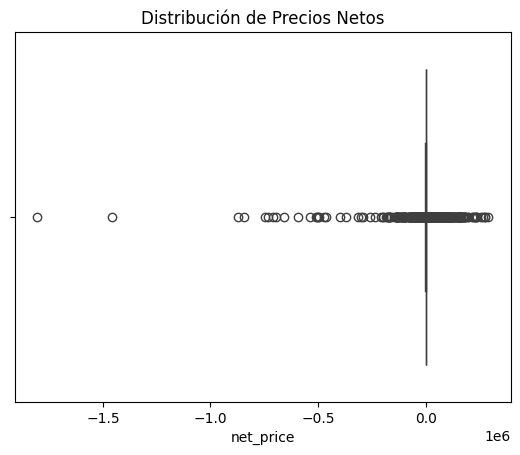

In [139]:
sns.boxplot(x=main['net_price'])
plt.title('Distribución de Precios Netos')
plt.show()

La venta neta se encuentra colapsada, dado que existen estos outliers antes mencionados. En este contexto se sabia perfectamente que existian estos valores, la intencion de esta seccion no era descubrirlos, sino, identificarlos

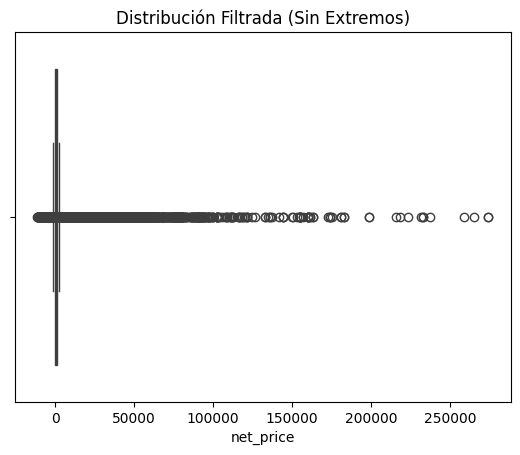

In [140]:
# la primera opcion va a ser quedarnos solo con lo que va del percentil 5 hasta el 1, e ir probando
# en que punto los datos son coherentes con lo que sucede en realidad
q_low = main["net_price"].quantile(0.0006)
q_hi  = main["net_price"].quantile(1)

main_wn_outs = main[(main["net_price"] < q_hi) & (main["net_price"] > q_low)]

sns.boxplot(x=main_wn_outs['net_price'])
plt.title('Distribución Filtrada (Sin Extremos)')
plt.show()

A pesar de que este último boxplot no es el ideal, si representa el comportamiento comercial de Urvet, ya que, manejan distribuidores mayoristas, los cuales cada cierto tiempo hacen consumos masivos, pero debido a que un 80% de sus clientes son distribuidores minoristas, existe este sesgo a la derecha.

- A nivel urvet, si es común ver estos picos en tickets, pero por esto mismo más adelante se evalúen opciones que reduzcan este comportamiento caótico por lo menos para los modelos. Esto a través de transformación logarítmica u otras alternativas.

/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/universidad/LIACD/S3/JAPI/venv/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0.5, 1.0, 'Venta Neta (Log Transform)')

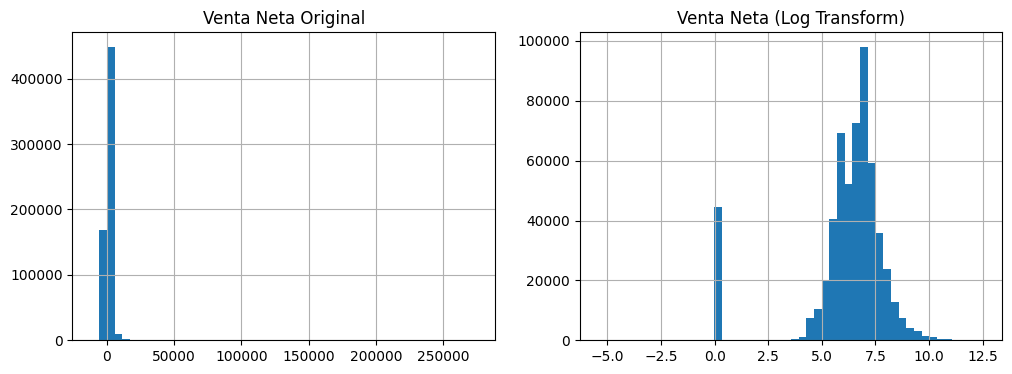

In [141]:
#Trasnformación logarítmica
main_wn_outs['net_price_log'] = np.log1p(main_wn_outs['net_price'])

#Comparación de distribuciones antes y después de la transformación logarítmica
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
main_wn_outs['net_price'].hist(ax=ax1, bins=50)
ax1.set_title('Venta Neta Original')
main_wn_outs['net_price_log'].hist(ax=ax2, bins=50)
ax2.set_title('Venta Neta (Log Transform)')

#### Análisis de Distribución de Venta Neta (Original vs. Transformada)

Al evaluar el comportamiento transaccional de la Venta Neta, el contraste entre la distribución original y su versión transformada revela información crítica sobre la operación de Urvet y define nuestra estrategia de modelado.

**1. Asimetría de Ventas (Gráfica Original)**
En su escala natural, los datos presentan una asimetría positiva extrema. La gran mayoría de las transacciones se concentra en el extremo inferior (valores bajos), mientras que una fracción mínima de facturas extiende la gráfica hacia sumas millonarias. Esto confirma la convivencia de dos perfiles en la base de datos: el volumen diario de pequeñas veterinarias y las compras esporádicas de alto impacto (distribuidores o grandes cuentas).

**2. Revelación del Comportamiento Real (Gráfica Transformada)**
Al aplicar la transformación logarítmica, logramos comprimir la escala y estabilizar la varianza. Esto hace emerger una distribución en forma de campana en los valores positivos, lo que nos permite visualizar la verdadera concentración del ticket promedio de la empresa, mitigando el ruido visual y matemático que generan los mayoristas.

**3. El Fenómeno de los Ceros y la Agregación Temporal**
En la distribución transformada destaca una columna masiva en la marca del cero, correspondiente a miles de tickets sin valor comercial (muestras, bonificaciones al 100% o regalos). Adicionalmente, sabemos que existen valores negativos derivados de las devoluciones. 

Para fines de este proyecto, la presencia de estos ceros y valores negativos a nivel transaccional no representa un obstáculo técnico. Nuestro objetivo predictivo no es a nivel factura, sino a nivel diario. Al momento de aplicar la agregación temporal para agrupar los datos por fecha, los tickets en cero no sumarán nada al total, y las devoluciones se compensarán naturalmente con la venta bruta del mismo día. 

El resultado de esta agregación será una serie de tiempo diaria robusta, estrictamente positiva y matemáticamente estable, lista para ser consumida de forma segura por los modelos de series de tiempo y aprendizaje profundo, esto con la tranformación logarítmica en los datos agregados `net_price`, ya que, si solo sumamos esta transformación por transacción, estaríamos haciendo una suma de logaritmos, lo que equivale a un producto.

In [142]:
# agrupación diaria con `sale_date` como índice
df_daily = (
    main_wn_outs
    .groupby('sale_date')
    .agg({
        'total_cost': 'sum',
        'net_price': 'sum',
        'gross_price': 'sum',
        'profit': 'sum',
        'quantity': 'sum',
        'route_id': 'nunique',
        'customer_id': 'nunique',
    })
)

# Rellenamos los días faltantes con 0
main_agg = (
    df_daily
    .resample('D')
    .asfreq()
    .fillna(0)
    .reset_index()
)

# Visualizamos el resultado
print(f"Rango de fechas: {main_agg['sale_date'].min()} a {main_agg['sale_date'].max()} \n")
main_agg

Rango de fechas: 2024-01-02 00:00:00 a 2026-03-31 00:00:00 



,sale_date,total_cost,net_price,gross_price,profit,quantity,route_id,customer_id
0,2024-01-02,"416,168.36","719,422.63","726,534.50","303,254.28","2,671.00",35.00,227.00
1,2024-01-03,"583,088.12","992,292.59","1,045,398.97","409,204.47","3,627.00",35.00,290.00
2,2024-01-04,"463,671.84","802,011.48","848,690.21","338,339.65","3,644.00",35.00,278.00
3,2024-01-05,"308,075.65","484,853.02","511,798.86","176,777.38","2,261.00",34.00,222.00
4,2024-01-06,"36,584.54","60,058.17","60,484.89","23,473.63",196.00,14.00,32.00
...,...,...,...,...,...,...,...,...
815,2026-03-27,"838,175.86","1,270,651.33","1,319,587.48","432,475.47","5,641.00",51.00,262.00
816,2026-03-28,0.00,0.00,0.00,0.00,0.00,0.00,0.00
817,2026-03-29,0.00,0.00,0.00,0.00,0.00,0.00,0.00
818,2026-03-30,"1,534,963.08","2,718,817.07","2,741,778.47","1,183,854.00","9,168.00",52.00,482.00


In [143]:
# trasnformación logarítmica de la venta neta agregada
main_agg['net_price_log'] = np.log1p(main_agg['net_price'])
main_agg

/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/universidad/LIACD/S3/JAPI/venv/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


,sale_date,total_cost,net_price,gross_price,profit,quantity,route_id,customer_id,net_price_log
0,2024-01-02,"416,168.36","719,422.63","726,534.50","303,254.28","2,671.00",35.00,227.00,13.49
1,2024-01-03,"583,088.12","992,292.59","1,045,398.97","409,204.47","3,627.00",35.00,290.00,13.81
2,2024-01-04,"463,671.84","802,011.48","848,690.21","338,339.65","3,644.00",35.00,278.00,13.59
3,2024-01-05,"308,075.65","484,853.02","511,798.86","176,777.38","2,261.00",34.00,222.00,13.09
4,2024-01-06,"36,584.54","60,058.17","60,484.89","23,473.63",196.00,14.00,32.00,11.00
...,...,...,...,...,...,...,...,...,...
815,2026-03-27,"838,175.86","1,270,651.33","1,319,587.48","432,475.47","5,641.00",51.00,262.00,14.06
816,2026-03-28,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
817,2026-03-29,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
818,2026-03-30,"1,534,963.08","2,718,817.07","2,741,778.47","1,183,854.00","9,168.00",52.00,482.00,14.82


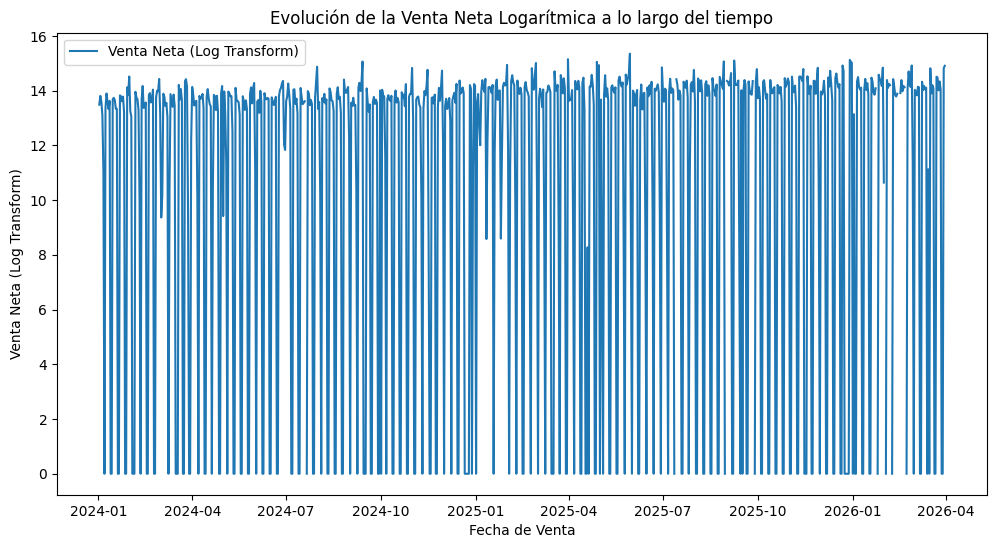

In [144]:
plt.figure(figsize=(12, 6))
plt.plot(main_agg['sale_date'], main_agg['net_price_log'], label='Venta Neta (Log Transform)')
plt.title('Evolución de la Venta Neta Logarítmica a lo largo del tiempo')
plt.xlabel('Fecha de Venta')
plt.ylabel('Venta Neta (Log Transform)')
plt.legend()
plt.show()

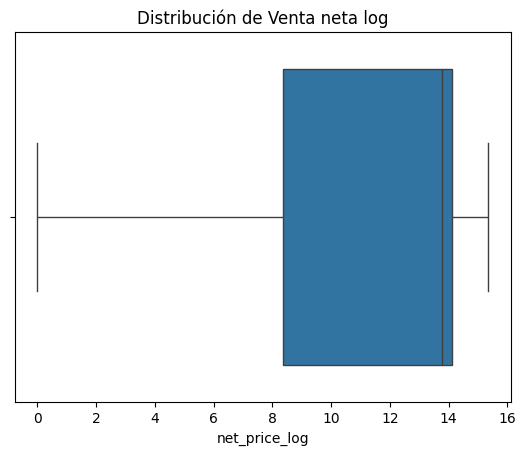

In [145]:
sns.boxplot(x=main_agg['net_price_log'])
plt.title('Distribución de Venta neta log')
plt.show()

Evolución Temporal y Distribución de Venta Neta Diaria (Logarítmica)

---

Una vez aplicada la agregación temporal a nivel diario y la transformación logarítmica, la serie de tiempo revela la verdadera dinámica operativa y financiera de la empresa, eliminando el sesgo de las transacciones atípicas individuales.

**1. Análisis de Estacionalidad y Estabilidad (Gráfico de Líneas)**
La serie temporal exhibe un patrón de estacionalidad semanal sumamente estricto. Las caídas recurrentes a cero en la serie representan los días inhábiles en la operación logística (principalmente domingos y días festivos oficiales). 

Omitiendo estos valles operativos, los niveles de facturación muestran una notable estabilidad a lo largo del periodo analizado, oscilando de manera consistente en la banda logarítmica de 13.5 a 14.5. Esto es un indicador de un modelo de negocio maduro y predecible, carente de fluctuaciones erráticas extremas que comprometan la convergencia de los modelos predictivos.

**2. Caracterización del Día Hábil Típico (Boxplot)**
El diagrama de caja diario presenta una asimetría negativa (sesgo hacia la izquierda). Esta prolongación del límite inferior es una consecuencia matemática directa de los cierres semanales en cero. 

Sin embargo, el rango intercuartílico superior es sumamente estrecho y la mediana se ubica sólidamente en el nivel 13.8. Al aplicar la transformación exponencial inversa a esta medida de tendencia central, confirmamos que el volumen de facturación estándar en un día hábil normal oscila de manera constante cerca del millón de pesos a nivel nacional.

**Implicaciones para la Arquitectura de Modelado:**
El comportamiento rítmico de la serie define la estrategia para los algoritmos predictivos:
* El modelo Prophet absorberá este patrón de forma nativa mediante su componente de estacionalidad semanal, complementado con la ingesta del calendario oficial de días festivos de México.
* Para asegurar la precisión del modelo SARIMAX y la red neuronal LSTM, será mandatorio generar variables exógenas binarias (indicadores de día laboral y día festivo). Esto proporcionará el contexto matemático necesario para que los algoritmos no interpreten los cierres logísticos semanales como caídas abruptas en la demanda del mercado.

In [146]:
main_agg.describe()

,sale_date,total_cost,net_price,gross_price,profit,quantity,route_id,customer_id,net_price_log
count,820,820.00,820.00,820.00,820.00,820.00,820.00,820.00,810.00
mean,2025-02-14 12:00:00,"573,013.93","893,600.08","922,256.70","320,586.15","3,927.85",29.21,203.38,10.35
min,2024-01-02 00:00:00,0.00,"-1,556.45",0.00,"-1,556.45",0.00,0.00,0.00,0.00
25%,2024-07-24 18:00:00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,8.36
50%,2025-02-14 12:00:00,"593,644.66","932,798.46","974,452.01","335,179.12","3,978.00",32.00,252.00,13.76
75%,2025-09-07 06:00:00,"871,611.35","1,356,141.61","1,398,915.65","481,671.65","5,935.50",50.00,313.00,14.12
max,2026-03-31 00:00:00,"3,109,372.67","4,633,339.51","4,661,942.22","1,523,966.85","30,583.00",66.00,668.00,15.35
std,NaN,"498,544.66","766,087.18","786,572.40","275,550.98","3,512.36",20.81,147.16,5.96


- Volúmen y Rango Temporal

---

El dataset agregado consta de 820 observaciones diarias, abarcando de manera ininterrumpida desde el 2 de enero de 2024 hasta el 31 de marzo de 2026. Al contar con más de dos años completos de historia, el conjunto de datos cumple con la longitud mínima estadística requerida para que los modelos predictivos puedan detectar y aprender estacionalidades anuales recurrentes.

- Tendencia Central y Estabilidad Financiera

---

La variable objetivo (`net_price`) presenta una facturación diaria promedio de 893,600 MXN, con una mediana (cuartil 50%) de 932,798 MXN. Que la mediana sea numéricamente superior al promedio confirma el sesgo introducido por los días inhábiles: la operación regular de la empresa sostiene un ticket diario cercano al millón de pesos, pero los cierres semanales en cero arrastran el promedio matemático hacia abajo. 

La utilidad bruta promedio asciende a 320,586 MXN diarios, lo que revela de manera macroscópica un margen de rentabilidad estable cercano al 35.8% sobre la venta neta.

- Picos de Operación y Dispersión

---

La desviación estándar de la venta neta es alta (766,087 MXN), lo cual es congruente con la varianza natural generada entre días hábiles y domingos. Sin embargo, el valor máximo de venta (4.6 millones de pesos en una sola jornada con más de 30,500 unidades físicas surtidas) indica eventos atípicos de extrema demanda o cierre de ciclos corporativos que deberán ser tratados con variables dummy.

- Alertas de Integridad de Datos

---

1. Fuga por Transformación Logarítmica: La columna `net_price_log` reporta un conteo de 810 días, perdiendo 10 registros respecto a la base general (820). Esto ocurre porque el valor mínimo de la venta neta es de -1,556.45 MXN (días donde las devoluciones superaron la facturación bruta). La función logarítmica arroja nulos (NaN) ante valores negativos, generando huecos en la serie de tiempo. Es mandatorio reemplazar la transformación clásica por Seno Hiperbólico Inverso (Arcsinh).


2.  Métricas de Identificadores: Las columnas `route_id` y `customer_id` figuran en el resumen descriptivo con cálculos de media y desviación estándar. Al ser etiquetas de clasificación enmascaradas como números, carecen de interpretación estadística. Serán convertidas a variables de tipo categórico para el análisis posterior.

In [148]:
# para mitigar de los valores nulos, se aplicará un Seno inverso hiperbólico
main_agg['net_price_asinh'] = np.arcsinh(main_agg['net_price'])
main_agg


,sale_date,total_cost,net_price,gross_price,profit,quantity,route_id,customer_id,net_price_log,net_price_asinh
0,2024-01-02,"416,168.36","719,422.63","726,534.50","303,254.28","2,671.00",35.00,227.00,13.49,14.18
1,2024-01-03,"583,088.12","992,292.59","1,045,398.97","409,204.47","3,627.00",35.00,290.00,13.81,14.50
2,2024-01-04,"463,671.84","802,011.48","848,690.21","338,339.65","3,644.00",35.00,278.00,13.59,14.29
3,2024-01-05,"308,075.65","484,853.02","511,798.86","176,777.38","2,261.00",34.00,222.00,13.09,13.78
4,2024-01-06,"36,584.54","60,058.17","60,484.89","23,473.63",196.00,14.00,32.00,11.00,11.70
...,...,...,...,...,...,...,...,...,...,...
815,2026-03-27,"838,175.86","1,270,651.33","1,319,587.48","432,475.47","5,641.00",51.00,262.00,14.06,14.75
816,2026-03-28,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
817,2026-03-29,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
818,2026-03-30,"1,534,963.08","2,718,817.07","2,741,778.47","1,183,854.00","9,168.00",52.00,482.00,14.82,15.51


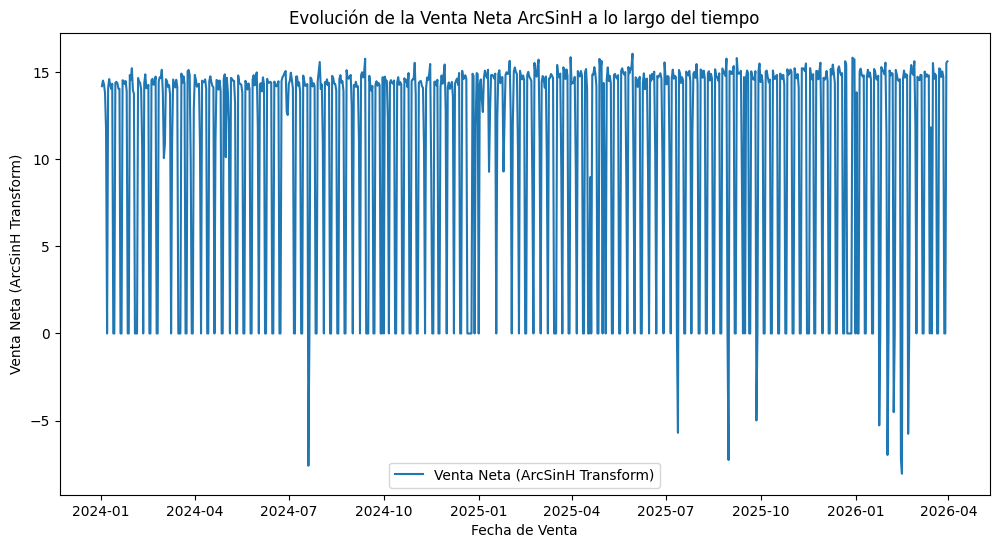

In [150]:
plt.figure(figsize=(12, 6))
plt.plot(main_agg['sale_date'], main_agg['net_price_asinh'], label='Venta Neta (ArcSinH Transform)')
plt.title('Evolución de la Venta Neta ArcSinH a lo largo del tiempo')
plt.xlabel('Fecha de Venta')
plt.ylabel('Venta Neta (ArcSinH Transform)')
plt.legend()
plt.show()

#### Pruebas de Hipótesis y Diagnóstico de la Serie Temporal

Para garantizar que los algoritmos predictivos converjan adecuadamente, es necesario someter la serie temporal a pruebas estadísticas formales. En lugar de depender exclusivamente de la intuición visual, validaremos los siguientes supuestos matemáticos sobre la Venta Neta (transformada mediante ArcSinH):

1. Evaluación de Estacionariedad (Prueba Aumentada de Dickey-Fuller - ADF)
* Hipótesis Nula (H0): La serie de tiempo posee una raíz unitaria (es no estacionaria). Su media y varianza cambian a lo largo del tiempo.
* Hipótesis Alternativa (H1): La serie no tiene raíz unitaria (es estacionaria).
* Impacto en Modelado: Los modelos de la familia ARIMA/SARIMAX exigen estacionariedad. Si fallamos en rechazar H0, sería necesario aplicar diferenciaciones (parámetro 'd') antes del entrenamiento.

2. Diagnóstico de Autocorrelación (Prueba de Ljung-Box)
* Hipótesis Nula (H0): Los datos se distribuyen de forma independiente (ausencia de autocorrelación, la serie es ruido blanco).
* Hipótesis Alternativa (H1): Existen rezagos (lags) pasados que están correlacionados con el valor actual.
* Impacto en Modelado: Rechazar H0 es el requisito fundamental para poder hacer predicciones. Si el pasado no explica el presente, el forecasting es imposible. Esta prueba define qué tan lejos debe mirar hacia atrás la red LSTM o el parámetro autorregresivo ('p').

3. Validación de Efecto de Calendario (Prueba de Kruskal-Wallis)
* Hipótesis Nula (H0): La mediana de la Venta Neta es igual para todos los días de la semana.
* Hipótesis Alternativa (H1): Al menos un día de la semana tiene una distribución de ventas significativamente distinta.
* Impacto en Modelado: Se utilizará una prueba no paramétrica (Kruskal-Wallis) debido a las variaciones observadas. Esto confirmará matemáticamente la estacionalidad semanal detectada en la inspección visual, obligando la creación de variables exógenas de calendario para el modelado.

In [151]:
main_agg.columns

Index(['sale_date', 'total_cost', 'net_price', 'gross_price', 'profit',
       'quantity', 'route_id', 'customer_id', 'net_price_log',
       'net_price_asinh'],
      dtype='str')

##### Prueba Aumentada de Dickey-Fuller (ADF)

##### Concepto de la prueba

La prueba Aumentada de Dickey-Fuller es una herramienta estadística fundamental en el análisis de series de tiempo. Su objetivo principal es determinar si una secuencia de datos es estacionaria. Una serie se considera estacionaria cuando sus propiedades estadísticas, como la media y la varianza, se mantienen constantes y no fluctúan debido a tendencias a largo plazo. Validar esta condición es un paso obligatorio antes de aplicar modelos estadísticos tradicionales, ya que algoritmos como SARIMAX asumen la estacionariedad de los datos como regla matemática para poder realizar proyecciones precisas.

##### Explicación matemática

El núcleo de la prueba ADF radica en identificar la presencia de una raíz unitaria dentro de un modelo autorregresivo. Si partimos de un proceso autorregresivo básico:

$$y_t = \rho y_{t-1} + \epsilon_t$$

Si el coeficiente es igual a uno ($\rho = 1$), la serie se comporta como un camino aleatorio continuo (no estacionaria) y se determina que tiene una raíz unitaria. Para evaluar esto estadísticamente, la ecuación original se reescribe restando el valor rezagado $y_{t-1}$ en ambos lados, obteniendo una ecuación de diferencias que incluye términos adicionales para capturar dinámicas más complejas:

$$\Delta y_t = \alpha + \beta t + \gamma y_{t-1} + \sum_{i=1}^{p} \delta_i \Delta y_{t-i} + \epsilon_t$$

Donde $\gamma = \rho - 1$. La prueba estadística concentra su evaluación sobre el coeficiente $\gamma$, estructurando el planteamiento bajo el siguiente par de hipótesis:

* **Hipótesis Nula ($H_0$):** $\gamma = 0$. La serie posee una raíz unitaria y, por lo tanto, es estrictamente no estacionaria.
* **Hipótesis Alternativa ($H_1$):** $\gamma < 0$. La serie no posee una raíz unitaria y demuestra ser estacionaria.

El estadístico de prueba calculado siempre arroja un valor negativo. Mientras más negativo sea el resultado, mayor será la certeza matemática para rechazar la hipótesis nula.

##### Desarrollo
Para el conjunto de datos actual, ejecutaremos la prueba ADF directamente sobre la columna `net_price_asinh`. Emplearemos un nivel de significancia estadístico estándar del 5% ($\alpha = 0.05$). Si el p-valor calculado resulta inferior a dicho umbral, confirmaremos matemáticamente que la estabilización de varianza aplicada previamente fue exitosa y la serie puede ser procesada por los algoritmos de forecasting sin requerir niveles de diferenciación adicionales.

In [156]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import kruskal

In [153]:


# aislamos la columna transformada y evitamos errores retirando valores nulos
serie_adf = main_agg['net_price_asinh'].dropna()

# ejecutamos la prueba aumentada de dickey-fuller sobre la serie
resultado_prueba = adfuller(serie_adf)

# extraemos el estadistico de prueba y el p-valor de la tupla devuelta
estadistico = resultado_prueba[0]
p_valor = resultado_prueba[1]


print("Resultados")
print(f"Estadístico: {estadistico:.4f}")
print(f"p-valor: {p_valor:.4e}")


if p_valor < 0.05:
    print("se rechaza la hipótesis nula. la serie temporal es estacionaria.")
else:
    print("no se rechaza la hipótesis nula. la serie temporal es no estacionaria.")

Resultados
Estadístico: -5.6416
p-valor: 1.0335e-06
se rechaza la hipótesis nula. la serie temporal es estacionaria.


##### Prueba de Ljung-Box

##### Concepto de la prueba

La prueba de Ljung-Box es una evaluación estadística diseñada para determinar si un conjunto de observaciones a lo largo del tiempo presenta dependencia temporal o si, por el contrario, se comporta de forma aleatoria (ruido blanco). A diferencia de otras pruebas que analizan rezagos (lags) de manera individual, este test examina de forma conjunta múltiples rezagos para evaluar la autocorrelación global de la serie. En el contexto de nuestro proyecto, ejecutar esta prueba sobre la serie de ventas netas transformadas nos permitirá justificar matemáticamente la viabilidad de usar modelos como SARIMAX y LSTM, demostrando que los datos históricos contienen "memoria" y son útiles para pronosticar el comportamiento de abril.

##### Explicación matemática

La prueba calcula un estadístico $Q$ que acumula las autocorrelaciones elevadas al cuadrado hasta un número determinado de rezagos $h$. La formulación matemática es la siguiente:

$$Q = n(n+2) \sum_{k=1}^{h} \frac{\hat{\rho}_k^2}{n-k}$$

Donde $n$ representa el tamaño de la muestra, $h$ es el número de rezagos evaluados y $\hat{\rho}_k$ es la autocorrelación muestral calculada para el rezago $k$. La estructura del planteamiento se basa en el siguiente par de hipótesis:

* **Hipótesis Nula ($H_0$):** Las autocorrelaciones hasta el rezago $h$ son cero. Los datos se distribuyen de manera completamente independiente y no existe correlación serial.
* **Hipótesis Alternativa ($H_1$):** Al menos una de las autocorrelaciones hasta el rezago $h$ es diferente de cero. Existe una dependencia temporal estructurada en los datos.

Bajo la hipótesis nula, el estadístico $Q$ se aproxima asintóticamente a una distribución chi-cuadrado con $h$ grados de libertad. Un estadístico $Q$ grande y un p-valor bajo indican que los datos recientes están fuertemente ligados a los datos pasados.

##### Desarrollo

Someteremos la columna `net_price_asinh` a la prueba de Ljung-Box. Dada la estacionalidad operativa detectada previamente en los diagramas de evolución de Urvet, evaluaremos la serie utilizando un horizonte de 7 rezagos (lags), lo cual encapsula un ciclo comercial semanal completo. Mantendremos el nivel de significancia del 5% ($\alpha = 0.05$). Al rechazar la hipótesis nula, confirmaremos de forma cuantitativa que la facturación diaria no es un evento aislado, sino que está altamente influenciada por las ventas de los días anteriores.

In [155]:
# definimos el numero de rezagos a evaluar basados en el ciclo logistico semanal
lags = [7]

# ejecución de  la prueba sobre la serie transformada retirando nulos si existieran
resultado_lb = acorr_ljungbox(main_agg['net_price_asinh'].dropna(), lags=lags, return_df=True)

# extraemos el estadistico y el p-valor del dataframe generado
estadistico_lb = resultado_lb.loc[7, 'lb_stat']
p_valor_lb = resultado_lb.loc[7, 'lb_pvalue']


print(f"Estadístico Q: {estadistico_lb:.4f}")
print(f"p-valor: {p_valor_lb:.4e}")


if p_valor_lb < 0.05:
    print("se rechaza la hipótesis nula. existe fuerte autocorrelación serial en los datos.")
else:
    print("no se rechaza la hipótesis nula. la serie carece de memoria temporal (ruido blanco).")

Estadístico Q: 847.6708
p-valor: 9.5414e-179
se rechaza la hipótesis nula. existe fuerte autocorrelación serial en los datos.


##### Prueba de Kruskal-Wallis

##### Concepto de la prueba

La prueba de Kruskal-Wallis es un método estadístico no paramétrico utilizado para determinar si existen diferencias estadísticamente significativas entre las medianas de tres o más grupos independientes. A diferencia del análisis de varianza tradicional (ANOVA), esta prueba no asume que los datos sigan una distribución normal, lo cual la hace ideal para la serie de ventas, que concentra un alto volumen de ceros y valores atípicos derivados de la operación logística. En el contexto de este proyecto, utilizaremos Kruskal-Wallis para agrupar las ventas netas diarias según el día de la semana. El objetivo es comprobar matemáticamente la estacionalidad semanal observada de forma empírica en los gráficos, demostrando que el nivel de facturación está directamente condicionado por el calendario.

##### Explicación matemática

El estadístico principal de Kruskal-Wallis (denotado frecuentemente como $H$) basa su cálculo en el ordenamiento por rangos. En primer lugar, se ordenan todas las observaciones del conjunto de datos de menor a mayor, ignorando temporalmente el grupo al que pertenecen, para asignarles un rango absoluto (desde 1 hasta $N$). Posteriormente, se calcula la suma de los rangos correspondientes a cada grupo individual.

La ecuación general para obtener el estadístico es:

$$H = \frac{12}{N(N+1)} \sum_{i=1}^{k} \frac{R_i^2}{n_i} - 3(N+1)$$

Donde $N$ es el número total de observaciones en la serie, $k$ es el número de grupos que se están comparando (los 7 días de la semana), $n_i$ es la cantidad de observaciones específicas en el grupo $i$, y $R_i$ representa la sumatoria total de los rangos para ese mismo grupo $i$.

El marco de decisión estadística se define mediante el siguiente par de hipótesis:

* **Hipótesis Nula ($H_0$):** Las distribuciones poblacionales (y sus medianas) son iguales para todos los días de la semana. No existe un efecto o sesgo de calendario.
* **Hipótesis Alternativa ($H_1$):** Al menos un día de la semana posee una distribución de ventas con una tendencia central significativamente distinta a la del resto de los grupos.

Si las ventas de los domingos se concentran en los rangos más bajos, el estadístico $H$ crecerá de forma acelerada. Bajo la hipótesis nula, $H$ se aproxima a una distribución chi-cuadrado con $k-1$ grados de libertad.

##### Desarrollo

Para la ejecución de esta prueba, el primer paso consiste en derivar una variable categórica desde la columna `sale_date` que clasifique cada registro en su día de la semana correspondiente (donde 0 es lunes y 6 es domingo). Posteriormente, la serie transformada `net_price_asinh` se particionará en siete arreglos independientes que se evaluarán de forma simultánea. Se mantendrá el nivel de significancia de $\alpha = 0.05$. El rechazo de la hipótesis nula se traducirá en un requerimiento formal de arquitectura: los modelos predictivos deberán ser alimentados forzosamente con variables dicotómicas (dummies) de calendario para converger con precisión.

In [157]:
# indicador del dia de la semana directamente del indice temporal
main_agg['day_of_week'] = main_agg['sale_date'].dt.dayofweek

# lista por comprension aislando las ventas para cada uno de los siete dias
datos_por_dia = [main_agg[main_agg['day_of_week'] == i]['net_price_asinh'].dropna() for i in range(7)]

# inyectamos los siete subconjuntos en el algoritmo desempaquetando la lista
estadistico_kw, p_valor_kw = kruskal(*datos_por_dia)

print(f"Estadístico H: {estadistico_kw:.4f}")
print(f"p-valor: {p_valor_kw:.4e}")

if p_valor_kw < 0.05:
    print("se rechaza la hipótesis nula. existe un marcado efecto del día de la semana sobre las ventas.")
else:
    print("no se rechaza la hipótesis nula. las distribuciones de ventas son homogeneas a lo largo de la semana.")

Estadístico H: 478.7256
p-valor: 3.2119e-100
se rechaza la hipótesis nula. existe un marcado efecto del día de la semana sobre las ventas.


#### Conclusión General y Hallazgos del Análisis Exploratorio (EDA)

Tras someter el conjunto de datos históricos de Urvet a un riguroso proceso de limpieza, agregación temporal y validación estadística, el Análisis Exploratorio de Datos concluye con los siguientes hallazgos definitivos, los cuales dictarán la arquitectura de los modelos predictivos para el pronóstico de ventas de abril de 2026.

_Comportamiento Transaccional y Estabilización Financiera_

El análisis de distribución reveló una fuerte asimetría positiva a nivel transaccional, dominada por un volumen masivo de tickets menores y compras esporádicas de alto valor corporativo. Al migrar hacia una agregación diaria, se descubrió un ticket de operación estándar sólido y constante, cercano al millón de pesos a nivel nacional. La aplicación de la transformación matemática ArcSinH (Seno Hiperbólico Inverso) fue un éxito crítico, permitió estabilizar la varianza de los grandes volúmenes manteniendo la integridad matemática de los días con flujo de caja negativo (devoluciones netas) y los cierres operativos en cero, evitando la alteración de la realidad financiera de la empresa.

---

_Diagnóstico de la Dinámica Temporal_

La serie agregada diariamente presenta un comportamiento altamente rítmico y predecible, dictado por la logística comercial del negocio B2B veterinario. Las pruebas estadísticas inferenciales aplicadas sobre la serie transformada arrojaron resultados concluyentes:
* Estacionariedad confirmada (Prueba ADF): Con un p-valor de $1.03 \times 10^{-6}$, se rechaza categóricamente la presencia de una raíz unitaria. La serie es matemáticamente estacionaria en su media y varianza transformada, garantizando la convergencia paramétrica.
* Fuerte memoria temporal (Prueba Ljung-Box): El p-valor de $9.54 \times 10^{-179}$ confirma una autocorrelación serial masiva. El volumen de venta de un día está directamente explicado por el comportamiento de los días previos, habilitando la viabilidad matemática del forecasting.
* Efecto de calendario innegable (Prueba Kruskal-Wallis): El estadístico H comprobó con un p-valor cercano a cero ($3.21 \times 10^{-100}$) que el día de la semana altera drásticamente la distribución de los ingresos, formalizando la estacionalidad visual detectada en los domingos y días festivos.

_Directrices de Arquitectura para el Equipo de Modelado_

Con base en estos hallazgos, el conjunto de datos está listo para la fase de entrenamiento bajo las siguientes reglas estrictas de implementación para el equipo:
* Para el modelo SARIMAX: Dado el resultado de la prueba ADF, el parámetro de diferenciación regular ($d$) debe configurarse en $0$.
* Para los modelos Prophet y LSTM: Es obligatorio realizar ingeniería de características (Feature Engineering) inyectando variables dicotómicas de calendario. Los algoritmos requieren marcadores exactos (`is_monday`, `is_holiday`, etc.) para comprender las caídas logísticas de la serie y no interpretarlas como colapsos en la demanda del mercado.
* Transformación Inversa: Todas las proyecciones resultantes para el mes de abril deberán someterse a la función Seno Hiperbólico (Sinh) antes de ser reportadas a la directiva, para devolver los valores a su escala original en moneda nacional.

El dataset final consolidado representa una base estadísticamente íntegra, libre de ruido atípico y lista para su consumo en la fase de Machine Learning y Deep Learning.